In [2]:
from astropy import units as u
from astropy.constants import k_B, R, G, c
import spacehub_calc
import numpy as np
import subprocess
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import display, clear_output, HTML
import seaborn as sns
import pandas as pd

#### Theoretical predictions



In [42]:
rho = (1e-9*u.g/(u.cm**(3))).si
print(rho.to(u.kg/u.cm**(3)))
T = 200*u.K
gamma = 5/3 #Monotomic gas
molarMass = 2.016 * u.g/u.mol
c_ideal = np.sqrt(gamma * R * T / molarMass)
c_ideal.to(u.km/u.s)


1.0000000000000002e-12 kg / cm3


<Quantity 1.17249555 km / s>

In [ ]:
M = 10 * u.Msun
Rs1 = 2*G*M/(c**2)
rho = (1e-9*u.g/(u.cm**(3))).si
deltaT = 1*u.yr
vrel = [1,0,0]*u.km/u.s
vmag = 1*u.km/u.s
Mach = vmag / c_ideal
I  = 0.5 * np.log((1+Mach)/(1-Mach))-Mach
# Delta p = F_dyn * Delta t
Fdyn = (I * vrel *(4 * np.pi * (G**2) * (M**2) * rho / (vmag**3))).si
dP = Fdyn*deltaT
(dP/M).to(u.km/u.s)

<Quantity [14533.4129385,     0.       ,     0.       ] km / s>

In [4]:
compilecmd = "g++ -std=c++17 -O3 -pthread simulations/dragforces/spTest.cpp -o simulations/dragforces/spTest"

if False:
    res = subprocess.run(compilecmd, capture_output=True, shell=True)
    print(res.stderr)
    res = subprocess.run("simulations/dragforces/spTest", capture_output=True, shell=True)
    print(res.stderr)
    print(res.stdout)

#### Data Processing

In [5]:
dfi = pd.read_csv("1+negligible.csv")
df = dfi[dfi["id"]==0]
df

,time,id,mass,radius,px,py,pz,vx,vy,vz
0,0.000000,0,1.0,0.000002,0.000000,0.000000,0.0,0.335742,0.000000,0.0
2,111.016579,0,1.0,0.000002,37.270085,-0.000735,0.0,0.335685,-0.000015,0.0
4,131.853538,0,1.0,0.000002,44.264578,-0.001098,0.0,0.335669,-0.000020,0.0
6,147.756338,0,1.0,0.000002,49.602530,-0.001451,0.0,0.335653,-0.000025,0.0
8,159.736944,0,1.0,0.000002,53.623769,-0.001772,0.0,0.335638,-0.000029,0.0
...,...,...,...,...,...,...,...,...,...,...
1304,1019.723879,0,1.0,0.000002,NaN,NaN,NaN,NaN,NaN,NaN
1306,1780.051806,0,1.0,0.000002,NaN,NaN,NaN,NaN,NaN,NaN
1308,3239.412384,0,1.0,0.000002,NaN,NaN,NaN,NaN,NaN,NaN
1310,6040.484419,0,1.0,0.000002,NaN,NaN,NaN,NaN,NaN,NaN


(-60.0, 60.0)

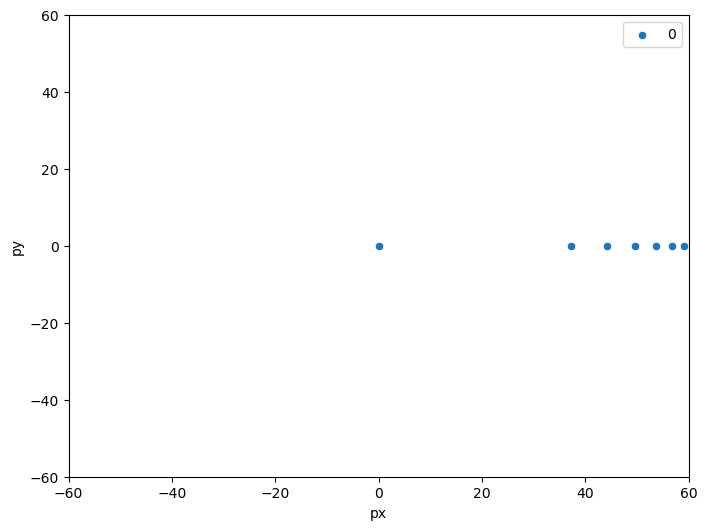

In [12]:
fig, ax = plt.subplots(figsize=(8,6)) 
sns.scatterplot(data=df, x="px", y="py", ax=ax, label="0")
#sns.scatterplot(data=df, x="time", y="vy", ax=ax)
#sns.scatterplot(data=df, x="time", y="vz", ax=ax)
ax.set_xlim(-60,60)
ax.set_ylim(-60,60)